# Stage 1 Final Overview

Decision-oriented overview for Stage 1 architecture search on `target_log_return_20m` with `price_hmm_n4` features.

Source run:

`s3://binance-data-downloader/dataset_target_20/with_price_hmm_n4/stage1_architecture_search/20260709_204850/`

## Executive Summary

- Final `stage1_results.parquet` exists in S3.
- Completed models: **99**.
- Original queue size in `run_config.json`: **135**.
- Completed families/losses: CatBoost RMSE, CatBoost RMSEWithUncertainty, LightGBM RMSE.
- Missing from the original plan: **CatBoost MultiQuantile, 36 models**.
- Best Stage 1 quality is from **CatBoost RMSEWithUncertainty**.
- Best RMSE: **0.00716098**, model `catboost_uncertainty_002_d4_lr0.03_l210`.
- Best direction accuracy at 0.25% threshold: **0.518447**, model `catboost_uncertainty_012_d6_lr0.03_l230`.
- LightGBM is much faster but materially weaker by RMSE in this run.

Main pruning decision:

- For CatBoost uncertainty, keep `depth=4/6`, mostly `learning_rate=0.03/0.05`; `depth=8/10` are not worth Stage 2 as primary RMSE candidates.
- Use `depth=6` variants only when direction accuracy is prioritized.
- Treat `learning_rate=0.1` as a low-priority edge case, not the center of Stage 2.
- Run MultiQuantile separately only if probabilistic intervals are required; it was not part of the completed final table.

## Setup

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "build_price_feature_day.py").exists():
        PROJECT_ROOT = candidate
        break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from build_price_feature_day import make_s3_client
from analysis.stage1_model_search.stage1_analysis_tools import (
    add_composite_score,
    early_stop_curve,
    hyperparameter_importance,
    load_stage1_results,
    parameter_columns,
    parameter_correlations,
    parameter_summary,
    pareto_frontier,
    plot_early_stop,
    plot_heatmap,
    plot_metric_distributions,
    plot_pareto,
    read_parquet,
    run_overview,
    stability_table,
    top_tables,
)

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_colwidth", 220)
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
BUCKET = "binance-data-downloader"
DATASET_PREFIX = "dataset_target_20/with_price_hmm_n4"
RESULTS_SUBDIR = "stage1_architecture_search"
RUN_ID = "latest"

s3 = make_s3_client()
loaded = load_stage1_results(
    s3=s3,
    bucket=BUCKET,
    dataset_prefix=DATASET_PREFIX,
    results_subdir=RESULTS_SUBDIR,
    run_id=RUN_ID,
)
results = add_composite_score(loaded.results)
run_config = loaded.run_config

print(loaded.active_s3_uri)
print(f"loaded_from_final_table={loaded.loaded_from_final_table}")
print(f"rows={len(results):,}")
run_config

s3://binance-data-downloader/dataset_target_20/with_price_hmm_n4/stage1_architecture_search/20260709_204850/
loaded_from_final_table=True
rows=99


{'run_id': '20260709_204850',
 'horizon': 20,
 'dataset_prefix': 'dataset_target_20/with_price_hmm_n4',
 'target_column': 'target_log_return_20m',
 'results_subdir': 'stage1_architecture_search',
 'output_prefix': 's3://binance-data-downloader/dataset_target_20/with_price_hmm_n4/stage1_architecture_search/20260709_204850/',
 'max_parallel_models': 1,
 'threads_per_model': 16,
 'reserved_vcpu_hint': 16,
 'direction_threshold': 0.0025,
 'hmm_feature_prefix': 'price_hmm_n4',
 'require_hmm_features': True,
 'include_lightgbm_quantile': False,
 'jobs': 135,
 'created_at_utc': '2026-07-10T05:59:46.697656+00:00'}

## 1. Completion Check

In [3]:
overview = run_overview(results, run_config)
overview

,expected_jobs,completed_jobs,coverage,families,loss_functions,total_train_time_hours,median_train_time_sec,best_RMSE,median_RMSE
0,135,99,0.733333,2,2,42.182454,1059.226838,0.007161,0.007256


In [4]:
completed_counts = results.groupby(["model_family", "loss_function"]).size().rename("completed").reset_index()
completed_counts

,model_family,loss_function,completed
0,catboost,RMSE,36
1,catboost,RMSEWithUncertainty,36
2,lightgbm,RMSE,27


Interpretation: the final table is complete for the **restarted non-MultiQuantile subset**, but not for the original 135-job plan. MultiQuantile should be treated as not evaluated in this Stage 1 conclusion.

## 2. Family-Level Result

In [5]:
family_summary = (
    results.groupby(["model_family", "loss_function"], dropna=False)
    .agg(
        jobs=("job_id", "count"),
        best_RMSE=("RMSE", "min"),
        median_RMSE=("RMSE", "median"),
        best_MAE=("MAE", "min"),
        best_DA_025=("Direction_Accuracy_0.25%", "max"),
        median_train_time=("train_time", "median"),
        median_model_size_mb=("model_size_mb", "median"),
    )
    .reset_index()
    .sort_values("best_RMSE")
)
family_summary

,model_family,loss_function,jobs,best_RMSE,median_RMSE,best_MAE,best_DA_025,median_train_time,median_model_size_mb
1,catboost,RMSEWithUncertainty,36,0.007161,0.007177,0.003815,0.518447,1902.406670,6.294274
0,catboost,RMSE,36,0.007203,0.007259,0.003826,0.517787,861.949346,3.953641
2,lightgbm,RMSE,27,0.007246,0.007312,0.003844,0.516691,193.188610,6.747096


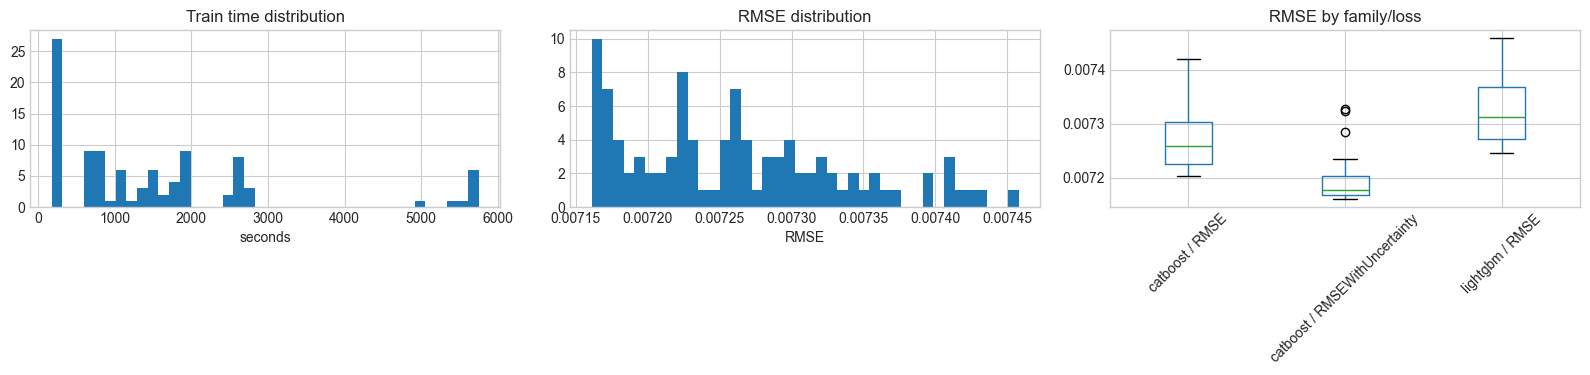

In [6]:
plot_metric_distributions(results)

## 3. Leaderboards

In [7]:
leaderboards = top_tables(results, n=10)
for name, table in leaderboards.items():
    print(f"\n{name}")
    display(table)


Top RMSE


,job_id,model_family,loss_function,RMSE,MAE,Direction_Accuracy_0.25%,CompositeScore,train_time,model_size_mb,params
37,catboost_uncertainty_002_d4_lr0.03_l210,catboost,RMSEWithUncertainty,0.007161,0.003815,0.516048,0.898214,1443.939761,0.933051,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03}"
36,catboost_uncertainty_001_d4_lr0.03_l23,catboost,RMSEWithUncertainty,0.007162,0.003817,0.515330,0.860459,1442.595689,0.933692,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03}"
40,catboost_uncertainty_005_d4_lr0.05_l210,catboost,RMSEWithUncertainty,0.007163,0.003817,0.516898,0.910459,1477.458530,0.941477,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.05}"
38,catboost_uncertainty_003_d4_lr0.03_l230,catboost,RMSEWithUncertainty,0.007163,0.003815,0.514934,0.829082,1456.534762,0.932742,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.03}"
45,catboost_uncertainty_010_d6_lr0.03_l23,catboost,RMSEWithUncertainty,0.007163,0.003817,0.517406,0.925000,1865.183968,3.051340,"{""bootstrap_type"": ""Bayesian"", ""depth"": 6, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03}"
46,catboost_uncertainty_011_d6_lr0.03_l210,catboost,RMSEWithUncertainty,0.007164,0.003816,0.518313,0.946173,1909.798120,2.999053,"{""bootstrap_type"": ""Bayesian"", ""depth"": 6, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03}"
41,catboost_uncertainty_006_d4_lr0.05_l230,catboost,RMSEWithUncertainty,0.007166,0.003816,0.516364,0.861990,1414.700201,0.940884,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.05}"
39,catboost_uncertainty_004_d4_lr0.05_l23,catboost,RMSEWithUncertainty,0.007166,0.003817,0.516963,0.873980,1446.992311,0.941712,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.05}"
43,catboost_uncertainty_008_d4_lr0.1_l210,catboost,RMSEWithUncertainty,0.007167,0.003820,0.515907,0.830612,1426.856129,0.949409,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.1}"
47,catboost_uncertainty_012_d6_lr0.03_l230,catboost,RMSEWithUncertainty,0.007168,0.003815,0.518447,0.925255,1902.160518,2.989563,"{""bootstrap_type"": ""Bayesian"", ""depth"": 6, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.03}"



Top MAE


,job_id,model_family,loss_function,RMSE,MAE,Direction_Accuracy_0.25%,CompositeScore,train_time,model_size_mb,params
37,catboost_uncertainty_002_d4_lr0.03_l210,catboost,RMSEWithUncertainty,0.007161,0.003815,0.516048,0.898214,1443.939761,0.933051,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03}"
38,catboost_uncertainty_003_d4_lr0.03_l230,catboost,RMSEWithUncertainty,0.007163,0.003815,0.514934,0.829082,1456.534762,0.932742,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.03}"
47,catboost_uncertainty_012_d6_lr0.03_l230,catboost,RMSEWithUncertainty,0.007168,0.003815,0.518447,0.925255,1902.160518,2.989563,"{""bootstrap_type"": ""Bayesian"", ""depth"": 6, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.03}"
46,catboost_uncertainty_011_d6_lr0.03_l210,catboost,RMSEWithUncertainty,0.007164,0.003816,0.518313,0.946173,1909.798120,2.999053,"{""bootstrap_type"": ""Bayesian"", ""depth"": 6, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03}"
41,catboost_uncertainty_006_d4_lr0.05_l230,catboost,RMSEWithUncertainty,0.007166,0.003816,0.516364,0.861990,1414.700201,0.940884,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.05}"
40,catboost_uncertainty_005_d4_lr0.05_l210,catboost,RMSEWithUncertainty,0.007163,0.003817,0.516898,0.910459,1477.458530,0.941477,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.05}"
36,catboost_uncertainty_001_d4_lr0.03_l23,catboost,RMSEWithUncertainty,0.007162,0.003817,0.515330,0.860459,1442.595689,0.933692,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03}"
39,catboost_uncertainty_004_d4_lr0.05_l23,catboost,RMSEWithUncertainty,0.007166,0.003817,0.516963,0.873980,1446.992311,0.941712,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.05}"
45,catboost_uncertainty_010_d6_lr0.03_l23,catboost,RMSEWithUncertainty,0.007163,0.003817,0.517406,0.925000,1865.183968,3.051340,"{""bootstrap_type"": ""Bayesian"", ""depth"": 6, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03}"
56,catboost_uncertainty_021_d8_lr0.03_l230,catboost,RMSEWithUncertainty,0.007173,0.003819,0.518095,0.879847,2790.941042,9.446704,"{""bootstrap_type"": ""Bayesian"", ""depth"": 8, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.03}"



Top Direction Accuracy


,job_id,model_family,loss_function,RMSE,MAE,Direction_Accuracy_0.25%,CompositeScore,train_time,model_size_mb,params
47,catboost_uncertainty_012_d6_lr0.03_l230,catboost,RMSEWithUncertainty,0.007168,0.003815,0.518447,0.925255,1902.160518,2.989563,"{""bootstrap_type"": ""Bayesian"", ""depth"": 6, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.03}"
46,catboost_uncertainty_011_d6_lr0.03_l210,catboost,RMSEWithUncertainty,0.007164,0.003816,0.518313,0.946173,1909.798120,2.999053,"{""bootstrap_type"": ""Bayesian"", ""depth"": 6, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03}"
55,catboost_uncertainty_020_d8_lr0.03_l210,catboost,RMSEWithUncertainty,0.007175,0.003821,0.518146,0.848724,2522.978795,9.472020,"{""bootstrap_type"": ""Bayesian"", ""depth"": 8, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03}"
56,catboost_uncertainty_021_d8_lr0.03_l230,catboost,RMSEWithUncertainty,0.007173,0.003819,0.518095,0.879847,2790.941042,9.446704,"{""bootstrap_type"": ""Bayesian"", ""depth"": 8, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.03}"
50,catboost_uncertainty_015_d6_lr0.05_l230,catboost,RMSEWithUncertainty,0.007178,0.003820,0.517899,0.833163,1887.787435,3.038583,"{""bootstrap_type"": ""Bayesian"", ""depth"": 6, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.05}"
49,catboost_uncertainty_014_d6_lr0.05_l210,catboost,RMSEWithUncertainty,0.007183,0.003820,0.517856,0.806378,1902.652823,3.046356,"{""bootstrap_type"": ""Bayesian"", ""depth"": 6, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.05}"
19,catboost_rmse_020_d8_lr0.03_l210,catboost,RMSE,0.007222,0.003841,0.517787,0.729592,1059.226838,6.056207,"{""bootstrap_type"": ""Bayesian"", ""depth"": 8, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03}"
58,catboost_uncertainty_023_d8_lr0.05_l210,catboost,RMSEWithUncertainty,0.007181,0.003830,0.517758,0.838010,1701.498287,9.911139,"{""bootstrap_type"": ""Bayesian"", ""depth"": 8, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.05}"
54,catboost_uncertainty_019_d8_lr0.03_l23,catboost,RMSEWithUncertainty,0.007174,0.003820,0.517584,0.869133,2603.958508,9.707394,"{""bootstrap_type"": ""Bayesian"", ""depth"": 8, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03}"
45,catboost_uncertainty_010_d6_lr0.03_l23,catboost,RMSEWithUncertainty,0.007163,0.003817,0.517406,0.925000,1865.183968,3.051340,"{""bootstrap_type"": ""Bayesian"", ""depth"": 6, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03}"



Top Composite Score


,job_id,model_family,loss_function,RMSE,MAE,Direction_Accuracy_0.25%,CompositeScore,train_time,model_size_mb,params
46,catboost_uncertainty_011_d6_lr0.03_l210,catboost,RMSEWithUncertainty,0.007164,0.003816,0.518313,0.946173,1909.798120,2.999053,"{""bootstrap_type"": ""Bayesian"", ""depth"": 6, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03}"
47,catboost_uncertainty_012_d6_lr0.03_l230,catboost,RMSEWithUncertainty,0.007168,0.003815,0.518447,0.925255,1902.160518,2.989563,"{""bootstrap_type"": ""Bayesian"", ""depth"": 6, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.03}"
45,catboost_uncertainty_010_d6_lr0.03_l23,catboost,RMSEWithUncertainty,0.007163,0.003817,0.517406,0.925000,1865.183968,3.051340,"{""bootstrap_type"": ""Bayesian"", ""depth"": 6, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03}"
40,catboost_uncertainty_005_d4_lr0.05_l210,catboost,RMSEWithUncertainty,0.007163,0.003817,0.516898,0.910459,1477.458530,0.941477,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.05}"
37,catboost_uncertainty_002_d4_lr0.03_l210,catboost,RMSEWithUncertainty,0.007161,0.003815,0.516048,0.898214,1443.939761,0.933051,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03}"
56,catboost_uncertainty_021_d8_lr0.03_l230,catboost,RMSEWithUncertainty,0.007173,0.003819,0.518095,0.879847,2790.941042,9.446704,"{""bootstrap_type"": ""Bayesian"", ""depth"": 8, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.03}"
39,catboost_uncertainty_004_d4_lr0.05_l23,catboost,RMSEWithUncertainty,0.007166,0.003817,0.516963,0.873980,1446.992311,0.941712,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.05}"
54,catboost_uncertainty_019_d8_lr0.03_l23,catboost,RMSEWithUncertainty,0.007174,0.003820,0.517584,0.869133,2603.958508,9.707394,"{""bootstrap_type"": ""Bayesian"", ""depth"": 8, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03}"
41,catboost_uncertainty_006_d4_lr0.05_l230,catboost,RMSEWithUncertainty,0.007166,0.003816,0.516364,0.861990,1414.700201,0.940884,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.05}"
36,catboost_uncertainty_001_d4_lr0.03_l23,catboost,RMSEWithUncertainty,0.007162,0.003817,0.515330,0.860459,1442.595689,0.933692,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03}"


RMSE winners are strongly concentrated in CatBoost RMSEWithUncertainty. Direction-accuracy winners shift toward `depth=6/8`, but the RMSE cost and train-time cost become visible quickly.

## 4. CatBoost Hyperparameter Pruning

In [8]:
catboost = results.loc[results["model_family"].eq("catboost")].copy()
catboost_uncertainty = catboost.loc[catboost["loss_function"].eq("RMSEWithUncertainty")].copy()

for param in ["param_depth", "param_learning_rate", "param_l2_leaf_reg"]:
    print(f"\n{param} across CatBoost")
    display(parameter_summary(catboost, param))

for param in ["param_depth", "param_learning_rate", "param_l2_leaf_reg"]:
    print(f"\n{param} for CatBoost RMSEWithUncertainty")
    display(parameter_summary(catboost_uncertainty, param))


param_depth across CatBoost


,param_depth,count,mean,median,std,best,worst,top10_count
0,4.0,18,0.007199,0.007190,0.000037,0.007161,0.007261,7
1,6.0,18,0.007218,0.007204,0.000051,0.007163,0.007327,3
2,8.0,18,0.007237,0.007226,0.000059,0.007173,0.007357,0
3,10.0,18,0.007286,0.007283,0.000074,0.007184,0.007420,0



param_learning_rate across CatBoost


,param_learning_rate,count,mean,median,std,best,worst,top10_count
0,0.03,24,0.007202,0.007201,0.000035,0.007161,0.007281,6
1,0.05,24,0.007226,0.007225,0.000048,0.007163,0.007323,3
2,0.10,24,0.007277,0.007273,0.000079,0.007167,0.007420,1



param_l2_leaf_reg across CatBoost


...

,param_depth,count,mean,median,std,best,worst,top10_count
0,4.0,9,0.007166,0.007166,0.000005,0.007161,0.007176,7
1,6.0,9,0.007177,0.007175,0.000012,0.007163,0.007194,3
2,8.0,9,0.007195,0.007181,0.000026,0.007173,0.007235,0
3,10.0,9,0.007242,0.007222,0.000056,0.007184,0.007327,0



param_learning_rate for CatBoost RMSEWithUncertainty


,param_learning_rate,count,mean,median,std,best,worst,top10_count
0,0.03,12,0.007173,0.007170,0.000012,0.007161,0.007198,6
1,0.05,12,0.007187,0.007179,0.000024,0.007163,0.007234,3
2,0.10,12,0.007225,0.007210,0.000058,0.007167,0.007327,1



param_l2_leaf_reg for CatBoost RMSEWithUncertainty


,param_l2_leaf_reg,count,mean,median,std,best,worst,top10_count
2,30.0,12,0.007192,0.007176,0.000035,0.007163,0.007284,3
0,3.0,12,0.007196,0.007176,0.000047,0.007162,0.007327,3
1,10.0,12,0.007197,0.007182,0.000047,0.007161,0.007324,4


param_learning_rate,0.03,0.05,0.10
param_depth,,,
4.0,0.007162,0.007166,0.007171
6.0,0.007164,0.007178,0.007194
8.0,0.007174,0.007181,0.007227
10.0,0.007189,0.007222,0.007324


param_l2_leaf_reg,3.0,10.0,30.0
param_depth,,,
4.0,0.007166,0.007163,0.007166
6.0,0.007175,0.007183,0.007173
8.0,0.007175,0.007181,0.007191
10.0,0.007222,0.007234,0.007216


param_l2_leaf_reg,3.0,10.0,30.0
param_learning_rate,,,
0.03,0.007169,0.007170,0.007170
0.05,0.007175,0.007182,0.007184
0.10,0.007214,0.007211,0.007199


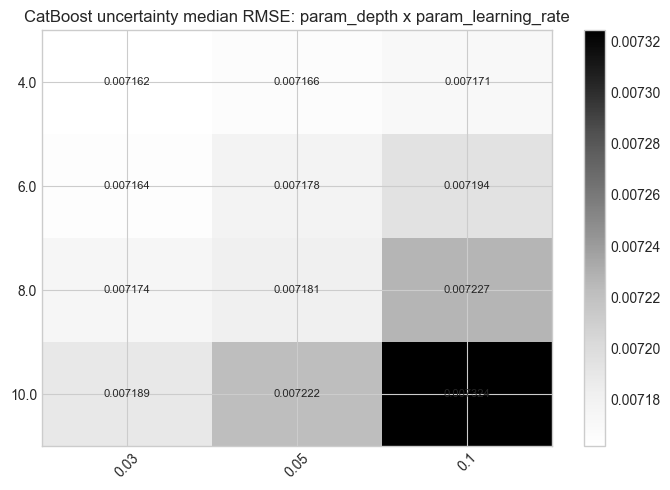

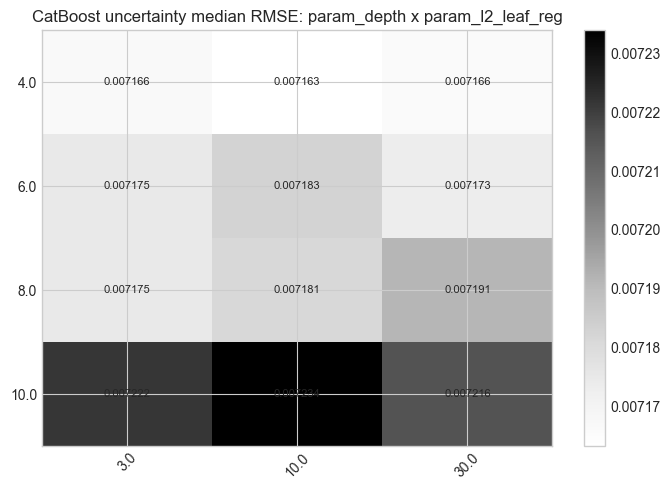

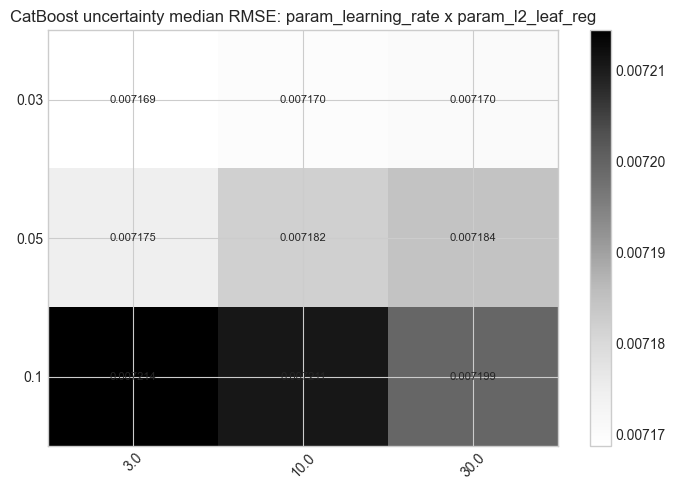

In [9]:
for row_param, col_param in [
    ("param_depth", "param_learning_rate"),
    ("param_depth", "param_l2_leaf_reg"),
    ("param_learning_rate", "param_l2_leaf_reg"),
]:
    pivot = catboost_uncertainty.pivot_table(index=row_param, columns=col_param, values="RMSE", aggfunc="median")
    display(pivot)
    plot_heatmap(pivot, title=f"CatBoost uncertainty median RMSE: {row_param} x {col_param}")

CatBoost pruning decision:

- Exclude `depth=10` from Stage 2.
- Exclude `depth=8` from RMSE-centered Stage 2, unless direction accuracy is the priority.
- Center Stage 2 around `depth=4/6`.
- Center learning rate around `0.03/0.05`.
- Keep all tested `l2_leaf_reg` values as seeds; differences are small, so regularization search is more useful than a hard l2 cutoff.

## 5. LightGBM Hyperparameter Pruning


param_num_leaves


,param_num_leaves,count,mean,median,std,best,worst,top10_count
0,31.0,9,0.007298,0.007268,0.000056,0.007246,0.007393,6
1,63.0,9,0.007331,0.007312,0.000058,0.007259,0.007427,2
2,127.0,9,0.007354,0.007333,0.000063,0.007290,0.007458,2



param_learning_rate


,param_learning_rate,count,mean,median,std,best,worst,top10_count
0,0.03,9,0.007275,0.007265,0.000022,0.007246,0.007300,7
1,0.05,9,0.007307,0.007312,0.000033,0.007263,0.007353,3
2,0.10,9,0.007401,0.007398,0.000034,0.007356,0.007458,0



param_max_depth


,param_max_depth,count,mean,median,std,best,worst,top10_count
2,10.0,9,0.007326,0.007302,0.000070,0.007246,0.007458,4
0,-1.0,9,0.007315,0.007312,0.000054,0.007253,0.007408,4
1,6.0,9,0.007342,0.007343,0.000064,0.007264,0.007431,2


param_learning_rate,0.03,0.05,0.10
param_num_leaves,,,
31.0,0.007253,0.007268,0.007365
63.0,0.007265,0.007312,0.007398
127.0,0.007298,0.007333,0.007431


param_learning_rate,0.03,0.05,0.10
param_max_depth,,,
-1.0,0.007265,0.007312,0.007373
6.0,0.007299,0.007343,0.007427
10.0,0.007259,0.007302,0.007398


param_num_leaves,31.0,63.0,127.0
param_max_depth,,,
-1.0,0.007263,0.007312,0.007312
6.0,0.007268,0.007343,0.007353
10.0,0.007275,0.007302,0.007333


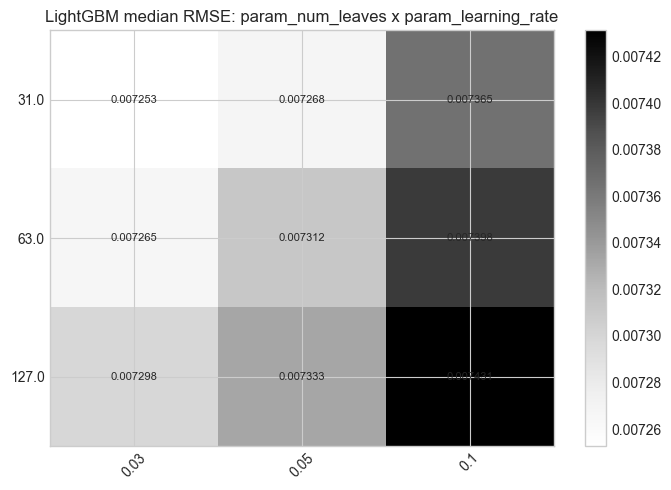

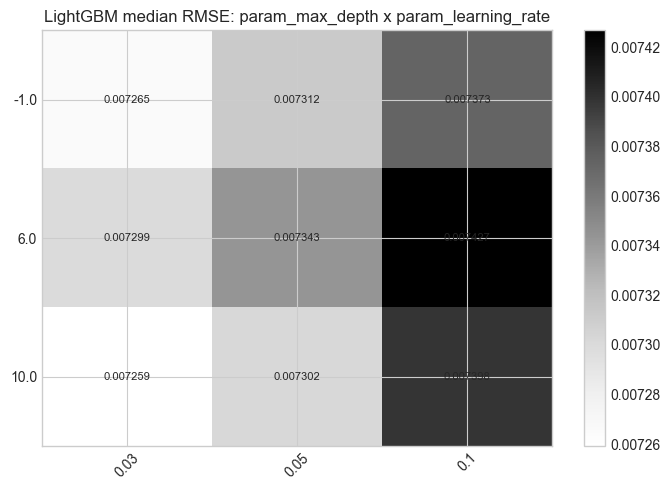

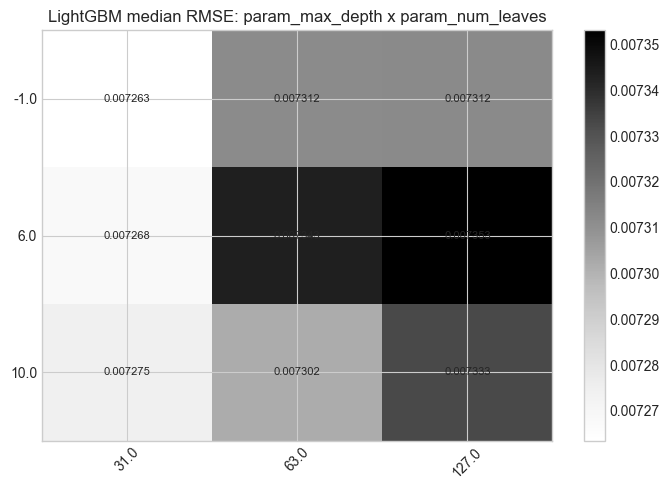

In [10]:
lightgbm = results.loc[results["model_family"].eq("lightgbm")].copy()
for param in ["param_num_leaves", "param_learning_rate", "param_max_depth"]:
    print(f"\n{param}")
    display(parameter_summary(lightgbm, param))

for row_param, col_param in [
    ("param_num_leaves", "param_learning_rate"),
    ("param_max_depth", "param_learning_rate"),
    ("param_max_depth", "param_num_leaves"),
]:
    pivot = lightgbm.pivot_table(index=row_param, columns=col_param, values="RMSE", aggfunc="median")
    display(pivot)
    plot_heatmap(pivot, title=f"LightGBM median RMSE: {row_param} x {col_param}")

LightGBM pruning decision:

- Keep LightGBM as a fast baseline and possible speed-quality Pareto candidate.
- For quality, LightGBM trails CatBoost uncertainty.
- Exclude `learning_rate=0.1`.
- Prefer `num_leaves=31`, then `63`; `127` is not attractive as a center.
- `max_depth=10` and `-1` are both viable; `6` is weaker but still cheap.

## 6. Cost-Quality Trade-Off

,job_id,model_family,loss_function,RMSE,MAE,Direction_Accuracy_0.25%,train_time,model_size_mb,params
37,catboost_uncertainty_002_d4_lr0.03_l210,catboost,RMSEWithUncertainty,0.007161,0.003815,0.516048,1443.939761,0.933051,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 10, ""learning_rate"": 0.03}"
36,catboost_uncertainty_001_d4_lr0.03_l23,catboost,RMSEWithUncertainty,0.007162,0.003817,0.515330,1442.595689,0.933692,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 3, ""learning_rate"": 0.03}"
41,catboost_uncertainty_006_d4_lr0.05_l230,catboost,RMSEWithUncertainty,0.007166,0.003816,0.516364,1414.700201,0.940884,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.05}"
2,catboost_rmse_003_d4_lr0.03_l230,catboost,RMSE,0.007203,0.003826,0.512031,624.755811,0.582537,"{""bootstrap_type"": ""Bayesian"", ""depth"": 4, ""iterations"": 3000, ""l2_leaf_reg"": 30, ""learning_rate"": 0.03}"
73,lightgbm_rmse_002_leaves31_lr0.03_depth10,lightgbm,RMSE,0.007246,0.003845,0.515119,182.496071,3.506932,"{""bagging_fraction"": 0.8, ""bagging_freq"": 1, ""feature_fraction"": 0.8, ""learning_rate"": 0.03, ""max_depth"": 10, ""n_estimators"": 3000, ""num_leaves"": 31}"
74,lightgbm_rmse_003_leaves31_lr0.03_depth-1,lightgbm,RMSE,0.007253,0.003844,0.515261,180.239131,3.499223,"{""bagging_fraction"": 0.8, ""bagging_freq"": 1, ""feature_fraction"": 0.8, ""learning_rate"": 0.03, ""max_depth"": -1, ""n_estimators"": 3000, ""num_leaves"": 31}"
77,lightgbm_rmse_006_leaves31_lr0.05_depth-1,lightgbm,RMSE,0.007263,0.003858,0.516691,176.619316,3.505328,"{""bagging_fraction"": 0.8, ""bagging_freq"": 1, ""feature_fraction"": 0.8, ""learning_rate"": 0.05, ""max_depth"": -1, ""n_estimators"": 3000, ""num_leaves"": 31}"
80,lightgbm_rmse_009_leaves31_lr0.1_depth-1,lightgbm,RMSE,0.007356,0.003901,0.515337,174.227849,3.507796,"{""bagging_fraction"": 0.8, ""bagging_freq"": 1, ""feature_fraction"": 0.8, ""learning_rate"": 0.1, ""max_depth"": -1, ""n_estimators"": 3000, ""num_leaves"": 31}"


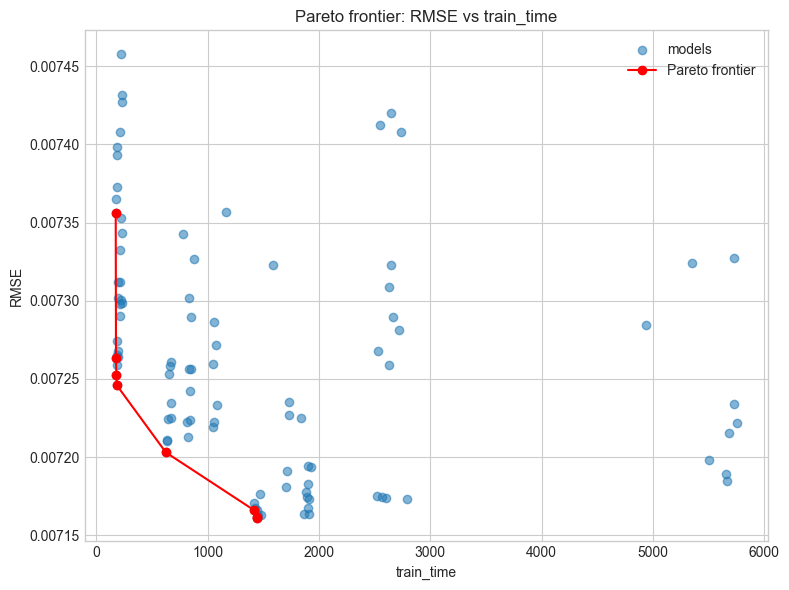

In [11]:
frontier = pareto_frontier(results, quality_metric="RMSE", cost_metric="train_time")
pareto_columns = ["job_id", "model_family", "loss_function", "RMSE", "MAE", "Direction_Accuracy_0.25%", "train_time", "model_size_mb", "params"]
display(frontier.loc[:, pareto_columns])
plot_pareto(results, frontier, quality_metric="RMSE", cost_metric="train_time")

In [12]:
stability_table(catboost_uncertainty, metric="RMSE", sizes=(5, 10, 20, 30))

,top_n,rows,best,worst,spread,spread_vs_best_pct,std
0,5,5,0.007161,0.007163,0.000002,0.034406,0.000001
1,10,10,0.007161,0.007168,0.000007,0.092163,0.000002
2,20,20,0.007161,0.007181,0.000020,0.280052,0.000006
3,30,30,0.007161,0.007225,0.000064,0.898223,0.000017


Top-10 CatBoost uncertainty RMSE spread is under 0.1% of the best result. This suggests Stage 2 should not chase deeper models; it should test regularization around the stable region.

## 7. Hyperparameter Importance

In [13]:
for label, frame in {
    "CatBoost uncertainty": catboost_uncertainty,
    "LightGBM RMSE": lightgbm,
}.items():
    importance, model, matrix = hyperparameter_importance(frame, metric="RMSE", param_cols=parameter_columns(frame))
    print(f"\n{label}")
    display(importance)

parameter_correlations(results)


CatBoost uncertainty


,parameter,rf_importance,permutation_importance_mean,permutation_importance_std
0,param_depth,0.575131,1.185534,0.344818
2,param_learning_rate,0.401802,0.751306,0.196040
1,param_l2_leaf_reg,0.023067,0.003664,0.002719



LightGBM RMSE


,parameter,rf_importance,permutation_importance_mean,permutation_importance_std
0,param_learning_rate,0.841937,1.463821,0.323303
2,param_num_leaves,0.118623,0.180578,0.035422
1,param_max_depth,0.039440,0.037690,0.012484


,parameter,target,spearman,pearson
4,param_depth,model_size_mb,0.968339,0.855430
24,param_num_leaves,model_size_mb,0.821156,0.847054
3,param_depth,train_time,0.745382,0.707133
23,param_num_leaves,train_time,0.727976,0.726739
1,param_depth,MAE,0.635398,0.609216
11,param_learning_rate,MAE,0.507359,0.571311
12,param_learning_rate,Direction_Accuracy_0.25%,-0.504114,-0.524955
0,param_depth,RMSE,0.494331,0.490438
10,param_learning_rate,RMSE,0.448052,0.496457
21,param_num_leaves,MAE,0.436785,0.414235


## 8. HMM Feature Importance Check

In [14]:
def load_feature_importance(row: pd.Series) -> pd.DataFrame:
    key = row.get("feature_importance_key")
    if not isinstance(key, str) or not key:
        return pd.DataFrame()
    frame = read_parquet(s3, BUCKET, key)
    if frame.empty:
        return frame
    frame = frame.copy()
    frame["job_id"] = row["job_id"]
    frame["model_family"] = row["model_family"]
    frame["loss_function"] = row["loss_function"]
    frame["RMSE"] = row["RMSE"]
    return frame

top_for_importance = results.sort_values(["RMSE", "MAE", "job_id"]).head(10)
feature_importance = pd.concat(
    [load_feature_importance(row) for _, row in top_for_importance.iterrows()],
    ignore_index=True,
) if len(top_for_importance) else pd.DataFrame()

if feature_importance.empty:
    print("No feature importance available")
else:
    feature_importance["importance_abs"] = feature_importance["importance"].abs()
    aggregate_importance = (
        feature_importance.groupby("feature", as_index=False)
        .agg(mean_abs_importance=("importance_abs", "mean"), jobs=("job_id", "nunique"))
        .sort_values("mean_abs_importance", ascending=False)
    )
    display(aggregate_importance.head(30))
    display(aggregate_importance.loc[aggregate_importance["feature"].str.startswith("price_hmm_n4_")])

,feature,mean_abs_importance,jobs
56,price_hmm_n4_prob_state_2,22.626000,10
57,price_hmm_n4_prob_state_3,17.134157,10
31,ada_realized_volatility_60m,16.044006,10
36,ada_return_std_60m,11.370860,10
30,ada_realized_volatility_20m,3.571799,10
58,time_of_day_cos,1.980245,10
59,time_of_day_sin,1.894290,10
55,price_hmm_n4_prob_state_1,1.605701,10
38,ada_trades_per_minute_5m,1.493088,10
43,ada_volume_sum_30m,1.359491,10


,feature,mean_abs_importance,jobs
56,price_hmm_n4_prob_state_2,22.626000,10
57,price_hmm_n4_prob_state_3,17.134157,10
55,price_hmm_n4_prob_state_1,1.605701,10
54,price_hmm_n4_prob_state_0,0.725040,10


## 9. Early-Stop Diagnostic

,models_seen,job_id,RMSE,best_so_far
2,1,catboost_rmse_003_d4_lr0.03_l230,0.007203,0.007203
0,2,catboost_rmse_001_d4_lr0.03_l23,0.007210,0.007203
1,3,catboost_rmse_002_d4_lr0.03_l210,0.007211,0.007203
3,4,catboost_rmse_004_d4_lr0.05_l23,0.007225,0.007203
4,5,catboost_rmse_005_d4_lr0.05_l210,0.007235,0.007203
36,6,catboost_uncertainty_001_d4_lr0.03_l23,0.007162,0.007162
37,7,catboost_uncertainty_002_d4_lr0.03_l210,0.007161,0.007161
38,8,catboost_uncertainty_003_d4_lr0.03_l230,0.007163,0.007161
5,9,catboost_rmse_006_d4_lr0.05_l230,0.007225,0.007161
39,10,catboost_uncertainty_004_d4_lr0.05_l23,0.007166,0.007161


,models_seen,job_id,RMSE,best_so_far
82,80,lightgbm_rmse_011_leaves63_lr0.03_depth10,0.007259,0.007161
81,81,lightgbm_rmse_010_leaves63_lr0.03_depth6,0.007299,0.007161
83,82,lightgbm_rmse_012_leaves63_lr0.03_depth-1,0.007265,0.007161
84,83,lightgbm_rmse_013_leaves63_lr0.05_depth6,0.007343,0.007161
85,84,lightgbm_rmse_014_leaves63_lr0.05_depth10,0.007302,0.007161
86,85,lightgbm_rmse_015_leaves63_lr0.05_depth-1,0.007312,0.007161
70,86,catboost_uncertainty_035_d10_lr0.1_l210,0.007324,0.007161
87,87,lightgbm_rmse_016_leaves63_lr0.1_depth6,0.007427,0.007161
88,88,lightgbm_rmse_017_leaves63_lr0.1_depth10,0.007398,0.007161
89,89,lightgbm_rmse_018_leaves63_lr0.1_depth-1,0.007373,0.007161


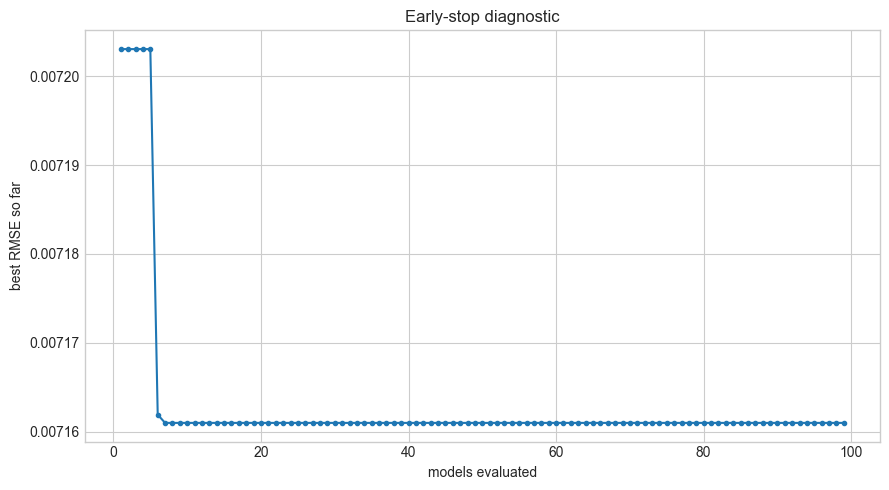

In [15]:
curve = early_stop_curve(results, metric="RMSE")
display(curve.head(20))
display(curve.tail(20))
plot_early_stop(curve, metric="RMSE")

## 10. Recommended Stage 2

Recommended main Stage 2 queue: **CatBoost RMSEWithUncertainty regularization search** around stable Stage 1 seeds.

Use this as the main queue because it wins RMSE and direction accuracy while keeping a stable top region.

In [16]:
ARCHITECTURE_SEEDS_STAGE2_MAIN = [
    {"depth": 4, "learning_rate": 0.03, "l2_leaf_reg": 10},
    {"depth": 4, "learning_rate": 0.03, "l2_leaf_reg": 3},
    {"depth": 4, "learning_rate": 0.03, "l2_leaf_reg": 30},
    {"depth": 4, "learning_rate": 0.05, "l2_leaf_reg": 10},
    {"depth": 4, "learning_rate": 0.05, "l2_leaf_reg": 30},
    {"depth": 6, "learning_rate": 0.03, "l2_leaf_reg": 3},
    {"depth": 6, "learning_rate": 0.03, "l2_leaf_reg": 10},
    {"depth": 6, "learning_rate": 0.03, "l2_leaf_reg": 30},
]

GRID_STAGE2_REGULARIZATION = {
    "bagging_temperature": [0, 1, 3, 5],
    "rsm": [0.7, 0.85, 1.0],
    "random_strength": [0, 1, 2],
}

stage2_main_jobs = len(ARCHITECTURE_SEEDS_STAGE2_MAIN)
for values in GRID_STAGE2_REGULARIZATION.values():
    stage2_main_jobs *= len(values)

stage2_main_jobs

288

Compact alternative if time is limited:

In [17]:
ARCHITECTURE_SEEDS_STAGE2_FAST = [
    {"depth": 4, "learning_rate": 0.03, "l2_leaf_reg": 10},
    {"depth": 4, "learning_rate": 0.03, "l2_leaf_reg": 30},
    {"depth": 6, "learning_rate": 0.03, "l2_leaf_reg": 10},
    {"depth": 6, "learning_rate": 0.03, "l2_leaf_reg": 30},
]

stage2_fast_jobs = len(ARCHITECTURE_SEEDS_STAGE2_FAST)
for values in GRID_STAGE2_REGULARIZATION.values():
    stage2_fast_jobs *= len(values)

stage2_fast_jobs

144

Secondary queues:

- CatBoost RMSE can be used as a point-forecast baseline, but it does not beat uncertainty loss.
- LightGBM RMSE is useful as a fast baseline or Pareto-speed model, centered on `num_leaves=31`, `learning_rate=0.03/0.05`, `max_depth=10/-1`.
- CatBoost MultiQuantile should be launched as a separate Stage 1 recovery run before including it in Stage 2 decisions.